In [44]:
!pip install xgboost imbalanced-learn shap

In [45]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import json, os, time
import json, time, csv, os, warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [46]:
demographic   = pd.read_csv('demographic.csv')
diet          = pd.read_csv('diet.csv')
examination   = pd.read_csv('examination.csv')
labs          = pd.read_csv('labs.csv')
medications   = pd.read_csv('medications.csv', encoding='latin1')
questionnaire = pd.read_csv('questionnaire.csv', encoding='latin1')
 

med_agg = medications.groupby('SEQN').agg(
    num_medications  = ('RXDDRUG', 'count'),   
    on_any_medication = ('RXDUSE', 'first')    
).reset_index()
 

merged = demographic.copy()
 
for df in [diet, examination, labs, med_agg, questionnaire]:
    merged = merged.merge(df, on='SEQN', how='left', suffixes=('', '_dup'))
 
merged.to_csv('nhanes_merged.csv', index=False)
 
print(merged.shape)

(10175, 1814)


In [47]:
df = pd.read_csv('nhanes_merged.csv')

#activity minutes: missing = 0 
activity_minutes = [
    'PAD615',  # vigorous work minutes/day
    'PAD630',  # moderate work minutes/day
    'PAD645',  # walk/bike minutes/day
    'PAD660',  # vigorous recreational minutes/day
    'PAD675',  # moderate recreational minutes/day
]
activity_days = [
    'PAQ610',  # days vigorous work/week
    'PAQ625',  # days moderate work/week
    'PAQ640',  # days walked/biked/week
    'PAQ655',  # days vigorous recreation/week
    'PAQ670',  # days moderate recreation/week
]
df[activity_minutes + activity_days] = df[activity_minutes + activity_days].fillna(0)
 
# total weekly activity minutes
df['total_active_min_per_week'] = (
    (df['PAD615'] * df['PAQ610']) +   # vigorous work
    (df['PAD630'] * df['PAQ625']) +   # moderate work
    (df['PAD645'] * df['PAQ640']) +   # walking/biking
    (df['PAD660'] * df['PAQ655']) +   # vigorous recreation
    (df['PAD675'] * df['PAQ670'])     # moderate recreation
)
 
# Smoking
df['SMD030'] = df['SMD030'].fillna(0)
 
# Alcohol
df['ALQ110'] = df['ALQ110'].fillna(0)
df['ALQ101'] = df['ALQ101'].fillna(0)
 
# Continuous clinical variables
median_cols = [
    'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST',  # body measures
    'LBXTC', 'LBDLDL', 'LBDHDD', 'LBXTR',    # cholesterol
    'LBXSGL', 'LBXIN', 'LBXGH',               # glucose/insulin/HbA1c
    'avg_systolic', 'avg_diastolic',            # blood pressure
    'PAD680',                                   # sedentary minutes
    'INDFMPIR',                                 # income ratio
    'DBD900', 'DBD910',                         # diet
]
for col in median_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
 
# Categorical variables
cat_cols = ['DMDEDUC2', 'SMQ020', 'DIQ010', 'BPQ020', 'on_any_medication']
for col in cat_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
 
df['num_medications'] = df['num_medications'].fillna(0)
 
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
 
print(f"Remaining missing values after cleaning:")
if len(remaining_missing) == 0:
    print("  None! Dataset is fully clean.")
else:
    print(remaining_missing)
 
print(f"\nNew feature added: total_active_min_per_week")
print(f"  Mean:   {df['total_active_min_per_week'].mean():.0f} min/week")
print(f"  Median: {df['total_active_min_per_week'].median():.0f} min/week")
print(f"\nFinal shape: {df.shape}")
 
df.to_csv('nhanes_clean.csv', index=False)
print(f"Saved as nhanes_clean.csv")
 

Remaining missing values after cleaning:
RIDAGEMN    9502
RIDEXMON     362
RIDEXAGM    5962
DMQMILIZ    3914
DMQADFC     9632
            ... 
WHD140      4072
WHQ150      4155
WHQ030M     8697
WHQ500      8697
WHQ520      8697
Length: 1753, dtype: int64

New feature added: total_active_min_per_week
  Mean:   463 min/week
  Median: 60 min/week

Final shape: (10175, 1815)
Saved as nhanes_clean.csv


In [48]:
demographics = [
    'SEQN',        # participant ID
    'RIAGENDR',    # sex (1=male, 2=female)
    'RIDAGEYR',    # age in years
    'RIDRETH3',    # race/ethnicity
    'INDFMPIR',    # poverty-income ratio (socioeconomic status)
    'DMDEDUC2',    # education level
]
 
#physical activity
activity = [
    'PAQ605',  # vigorous work activity (yes/no)
    'PAQ610',  # days of vigorous work activity per week
    'PAD615',  # minutes of vigorous work activity per day
    'PAQ620',  # moderate work activity (yes/no)
    'PAQ625',  # days of moderate work activity per week
    'PAD630',  # minutes of moderate work activity per day
    'PAQ635',  # walk or bicycle for transport (yes/no)
    'PAQ640',  # days walked/biked per week
    'PAD645',  # minutes walked/biked per day
    'PAQ650',  # vigorous recreational activity (yes/no)
    'PAQ655',  # days of vigorous recreational activity per week
    'PAD660',  # minutes of vigorous recreational activity per day
    'PAQ665',  # moderate recreational activity (yes/no)
    'PAQ670',  # days of moderate recreational activity per week
    'PAD675',  # minutes of moderate recreational activity per day
    'PAD680',  # minutes sedentary per day
]
 
body_measures = [
    'BMXWT',      # weight (kg)
    'BMXHT',      # height (cm)
    'BMXBMI',     # BMI
    'BMXWAIST',   # waist circumference (cm)
]
 
lab_results = [
    'LBXGH',    # HbA1c % — key diabetes risk marker 
    'LBXTC',    # total cholesterol
    'LBDLDL',   # LDL cholesterol
    'LBDHDD',   # HDL cholesterol
    'LBXTR',    # triglycerides
    'LBXSGL',   # glucose (non-fasting)
    'LBXIN',    # insulin
]
 
blood_pressure = [
    'BPXSY1',   # systolic BP reading 1
    'BPXDI1',   # diastolic BP reading 1
    'BPXSY2',   # systolic BP reading 2
    'BPXDI2',   # diastolic BP reading 2
]
 
lifestyle = [
    'SMQ020',   # smoked at least 100 cigarettes in life (yes/no)
    'SMD030',   # age started smoking
    'ALQ101',   # had at least 12 drinks in past year (yes/no)
    'ALQ110',   # had at least 12 drinks in life (yes/no)
    'DBD900',   # how many meals from fast food per week
    'DBD910',   # how many ready-to-eat foods per week
]
 
medications = [
    'num_medications',    # total number of medications (engineered)
    'on_any_medication',  # whether on any medication (engineered)
]
 
# self-reported diagnosis 
self_reported = [
    'DIQ010',   # told by doctor they have diabetes (yes/no)
    'BPQ020',   # told by doctor they have high blood pressure (yes/no)
]
 
all_cols = demographics + activity + body_measures + lab_results + blood_pressure + lifestyle + medications + self_reported
df_selected = df[all_cols].copy()

In [49]:
#average the two BP readings 
df_selected['avg_systolic']  = df_selected[['BPXSY1', 'BPXSY2']].mean(axis=1)
df_selected['avg_diastolic'] = df_selected[['BPXDI1', 'BPXDI2']].mean(axis=1)
 
#prediabetes risk flag: HbA1c >= 5.7% (ADA threshold)
df_selected['prediabetes_risk'] = (df_selected['LBXGH'] >= 5.7).astype(int)
 
#hypertension risk flag: systolic >= 130 OR diastolic >= 80 (ACC/AHA threshold)
df_selected['hypertension_risk'] = (
    (df_selected['avg_systolic'] >= 130) |
    (df_selected['avg_diastolic'] >= 80)
).astype(int)
 
#combined target: at risk for either condition
df_selected['high_risk'] = (
    (df_selected['prediabetes_risk'] == 1) |
    (df_selected['hypertension_risk'] == 1)
).astype(int)
 
print(f"Dataset shape: {df_selected.shape}")
print(f"\nTarget variable breakdown:")
print(f"  Prediabetes risk (HbA1c >= 5.7%):        {df_selected['prediabetes_risk'].sum():,} ({df_selected['prediabetes_risk'].mean():.1%})")
print(f"  Hypertension risk (BP >= 130/80):         {df_selected['hypertension_risk'].sum():,} ({df_selected['hypertension_risk'].mean():.1%})")
print(f"  High risk (either condition):             {df_selected['high_risk'].sum():,} ({df_selected['high_risk'].mean():.1%})")
print(f"\nMissing values (top 10):")
print(df_selected.isnull().sum().sort_values(ascending=False).head(10))

df_selected.to_csv('nhanes_selected.csv', index=False)
print(f"\nSaved as nhanes_selected.csv")

Dataset shape: (10175, 52)

Target variable breakdown:
  Prediabetes risk (HbA1c >= 5.7%):        2,109 (20.7%)
  Hypertension risk (BP >= 130/80):         2,087 (20.5%)
  High risk (either condition):             3,218 (31.6%)

Missing values (top 10):
PAQ665          3030
PAQ650          3028
PAQ635          3028
PAQ605          3027
PAQ620          3027
BPXSY1          3003
BPXDI1          3003
BPXSY2          2766
BPXDI2          2766
avg_systolic    2666
dtype: int64

Saved as nhanes_selected.csv


In [50]:
df = pd.read_csv('nhanes_selected.csv')

median_cols = ['BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST', 'LBXTC', 'LBDLDL',
               'LBDHDD', 'LBXTR', 'LBXSGL', 'LBXIN', 'LBXGH',
               'avg_systolic', 'avg_diastolic', 'PAD680', 'INDFMPIR',
               'DBD900', 'DBD910']
for col in median_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df['num_medications'] = df['num_medications'].fillna(0)

drop_cols = ['SEQN', 'high_risk', 'prediabetes_risk', 'hypertension_risk',
             'DIQ010', 'BPQ020',
             'BPXSY1', 'BPXDI1',
             'BPXSY2', 'BPXDI2',
             'LBXGH',
             'avg_systolic', 'avg_diastolic']

features = [c for c in df.columns if c not in drop_cols]
X = df[features]
y = df['high_risk']

activity_flags = ['PAQ605', 'PAQ620', 'PAQ635', 'PAQ650', 'PAQ665']
for col in activity_flags:
    if col in X.columns:
        X[col] = X[col].fillna(0)

print(f"Features used: {len(features)}")
print(f"Class balance: {y.value_counts().to_dict()}")

# LOCKED TEST SET 
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

test_indices = X_test.index.tolist()
with open('locked_test_indices.json', 'w') as f:
    json.dump(test_indices, f)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"\nTrain: {len(X_train):,} | Val: {len(X_val):,} | Test (locked): {len(X_test):,}")
print(f"Test set locked → saved to locked_test_indices.json")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ── BASELINE MODEL 
start = time.time()
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
elapsed = round(time.time() - start, 2)

y_pred      = model.predict(X_val_scaled)
y_pred_prob = model.predict_proba(X_val_scaled)[:, 1]

auc = roc_auc_score(y_val, y_pred_prob)
cm  = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
overall_tpr = tp / (tp + fn)

print(f"\n── BASELINE RESULTS (validation set) ────────────")
print(f"AUC-ROC:     {auc:.4f}")
print(f"Overall TPR: {overall_tpr:.4f}")
print(f"Runtime:     {elapsed}s")
print(f"\n{classification_report(y_val, y_pred)}")

# ── SUBGROUP FAIRNESS TABLE 
test_df = X_val.copy()
test_df['y_true'] = y_val.values
test_df['y_pred'] = y_pred
test_df['y_prob'] = y_pred_prob

def subgroup_metrics(df, group_col, group_labels):
    results = []
    for code, label in group_labels.items():
        sub = df[df[group_col] == code]
        if len(sub) < 20:
            continue
        sub_cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1])
        if sub_cm.shape == (2,2):
            _, _, fn_s, tp_s = sub_cm.ravel()
            tpr = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
        else:
            tpr = 0
        auc_s = roc_auc_score(sub['y_true'], sub['y_prob']) if sub['y_true'].nunique() > 1 else None
        results.append({'group': label, 'n': len(sub),
                        'tpr': round(tpr, 4),
                        'auc': round(auc_s, 4) if auc_s else 'N/A'})
    return pd.DataFrame(results)

sex_labels  = {1: 'Male', 2: 'Female'}
race_labels = {1: 'Mexican American', 2: 'Other Hispanic',
               3: 'Non-Hispanic White', 4: 'Non-Hispanic Black',
               6: 'Non-Hispanic Asian', 7: 'Other/Multi'}

test_df['age_group'] = pd.cut(test_df['RIDAGEYR'],
    bins=[0, 17, 34, 49, 64, 80],
    labels=['0-17', '18-34', '35-49', '50-64', '65-80'])

print("\n── SUBGROUP FAIRNESS (Sex) ───────────────────────")
sex_table = subgroup_metrics(test_df, 'RIAGENDR', sex_labels)
print(sex_table.to_string(index=False))

print("\n── SUBGROUP FAIRNESS (Race/Ethnicity) ───────────")
race_table = subgroup_metrics(test_df, 'RIDRETH3', race_labels)
print(race_table.to_string(index=False))

age_results = []
for age_grp in ['0-17', '18-34', '35-49', '50-64', '65-80']:
    sub = test_df[test_df['age_group'] == age_grp]
    if len(sub) < 20 or sub['y_true'].nunique() < 2:
        continue
    sub_cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1])
    if sub_cm.shape == (2,2):
        _, _, fn_s, tp_s = sub_cm.ravel()
        tpr = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
    else:
        tpr = 0
    auc_s = roc_auc_score(sub['y_true'], sub['y_prob'])
    age_results.append({'group': age_grp, 'n': len(sub),
                        'tpr': round(tpr, 4), 'auc': round(auc_s, 4)})
age_table = pd.DataFrame(age_results)
print("\n── SUBGROUP FAIRNESS (Age Group) ────────────────")
print(age_table.to_string(index=False))

all_tprs = list(sex_table['tpr']) + list(race_table['tpr']) + list(age_table['tpr'])
eq_odds_gap = round(max(all_tprs) - min(all_tprs), 4)
print(f"\n── EQUALIZED ODDS GAP: {eq_odds_gap} ──────────────────")
print(f"   Target: ≤ 0.05 | {'PASS ✓' if eq_odds_gap <= 0.05 else 'FAIL ✗ — agent needs to address this'}")

baseline_results = {
    "model": "logistic_regression",
    "auc_roc": round(auc, 4),
    "overall_tpr": round(overall_tpr, 4),
    "equalized_odds_gap": eq_odds_gap,
    "runtime_seconds": elapsed,
    "n_features": len(features),
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test)
}
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print(f"\nBaseline saved → baseline_results.json")

Features used: 39
Class balance: {0: 6957, 1: 3218}

Train: 6,512 | Val: 1,628 | Test (locked): 2,035
Test set locked → saved to locked_test_indices.json

── BASELINE RESULTS (validation set) ────────────
AUC-ROC:     0.9213
Overall TPR: 0.7573
Runtime:     0.04s

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1113
           1       0.76      0.76      0.76       515

    accuracy                           0.85      1628
   macro avg       0.82      0.82      0.82      1628
weighted avg       0.85      0.85      0.85      1628


── SUBGROUP FAIRNESS (Sex) ───────────────────────
 group   n    tpr    auc
  Male 823 0.7761 0.9128
Female 805 0.7368 0.9304

── SUBGROUP FAIRNESS (Race/Ethnicity) ───────────
             group   n    tpr    auc
  Mexican American 282 0.7600 0.9461
    Other Hispanic 149 0.7750 0.9339
Non-Hispanic White 601 0.8048 0.9068
Non-Hispanic Black 350 0.7063 0.9317
Non-Hispanic Asian 173 0.6800 0.9393
       O

In [51]:
import json
import csv
import time
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# ----------------------------
# 1) Load locked artifacts
# ----------------------------
with open("baseline_results.json", "r") as f:
    baseline = json.load(f)

with open("locked_test_indices.json", "r") as f:
    locked_test_indices = set(json.load(f))

print("Loaded baseline + locked test indices")
print(f"Baseline AUC: {baseline['auc_roc']:.4f} | Baseline EqOdds gap: {baseline['equalized_odds_gap']:.4f}")
print(f"Locked test rows: {len(locked_test_indices)}")

# ----------------------------
# 2) Rebuild data and keep test locked out
# ----------------------------
df = pd.read_csv("nhanes_selected.csv")

median_cols = [
    'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST', 'LBXTC', 'LBDLDL',
    'LBDHDD', 'LBXTR', 'LBXSGL', 'LBXIN', 'LBXGH',
    'avg_systolic', 'avg_diastolic', 'PAD680', 'INDFMPIR',
    'DBD900', 'DBD910'
]
for col in median_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df['num_medications'] = df['num_medications'].fillna(0)

activity_flags = ['PAQ605', 'PAQ620', 'PAQ635', 'PAQ650', 'PAQ665']
for col in activity_flags:
    if col in df.columns:
        df[col] = df[col].fillna(0)

drop_cols = [
    'SEQN', 'high_risk', 'prediabetes_risk', 'hypertension_risk',
    'DIQ010', 'BPQ020',
    'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2',
    'LBXGH', 'avg_systolic', 'avg_diastolic'
]

features = [c for c in df.columns if c not in drop_cols]
X = df[features].copy()
y = df['high_risk'].copy()

# strictly remove locked test rows from researcher loop
test_mask = X.index.isin(locked_test_indices)
X_train_val = X.loc[~test_mask].copy()
y_train_val = y.loc[~test_mask].copy()

# same val fraction as baseline (1628 / (6512 + 1628) = 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val,
)

print(f"Research split (train/val only): {len(X_train)} / {len(X_val)}")
print(f"Locked test excluded from all experiments: {len(locked_test_indices)} rows")

# ----------------------------
# 3) Fairness helpers (sex/age/race)
# ----------------------------
def _group_rates(y_true, y_pred, mask):
    yt = y_true[mask]
    yp = y_pred[mask]
    if yt.size < 20 or np.unique(yt).size < 2:
        return None
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return tpr, fpr

def equalized_odds_gap(y_true, y_pred, subgroup_df):
    y_true_np = np.asarray(y_true)
    y_pred_np = np.asarray(y_pred)

    # Age buckets consistent with baseline cell
    age_bucket = pd.cut(
        subgroup_df['RIDAGEYR'],
        bins=[0, 17, 34, 49, 64, 80],
        labels=['0-17', '18-34', '35-49', '50-64', '65-80']
    )

    axes = {
        'sex': subgroup_df['RIAGENDR'],
        'race': subgroup_df['RIDRETH3'],
        'age': age_bucket
    }

    per_axis = {}
    all_tprs, all_fprs = [], []

    for axis_name, series in axes.items():
        tprs, fprs = [], []
        for val in series.dropna().unique():
            mask = (series.values == val)
            rates = _group_rates(y_true_np, y_pred_np, mask)
            if rates is None:
                continue
            tpr, fpr = rates
            if not np.isnan(tpr):
                tprs.append(tpr)
                all_tprs.append(tpr)
            if not np.isnan(fpr):
                fprs.append(fpr)
                all_fprs.append(fpr)

        tpr_gap = (max(tprs) - min(tprs)) if len(tprs) >= 2 else np.nan
        fpr_gap = (max(fprs) - min(fprs)) if len(fprs) >= 2 else np.nan
        axis_gap = np.nanmax([tpr_gap, fpr_gap])
        per_axis[axis_name] = axis_gap

    overall_tpr_gap = (max(all_tprs) - min(all_tprs)) if len(all_tprs) >= 2 else np.nan
    overall_fpr_gap = (max(all_fprs) - min(all_fprs)) if len(all_fprs) >= 2 else np.nan
    overall_gap = np.nanmax([overall_tpr_gap, overall_fpr_gap])

    return overall_gap, per_axis

# ----------------------------
# 4) Auto-researcher experiment set
# ----------------------------
# Iterations now include mixed model families (linear + tree boosting).
experiments = [
    {
        'name': 'iter_1_lr_baseline_repro',
        'model_key': 'logistic_regression',
        'model': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
        'use_scaler': True,
        'threshold_mode': 'fixed_0.50',
        'changes_made': 'baseline logistic regression (no tuning)',
        'notes': 'Reference baseline to compare all later model families.'
    },
    {
        'name': 'iter_2_lr_balanced',
        'model_key': 'logistic_regression',
        'model': LogisticRegression(max_iter=1200, random_state=42, C=1.0, class_weight='balanced'),
        'use_scaler': True,
        'threshold_mode': 'fixed_0.50',
        'changes_made': 'logistic regression with class_weight=balanced',
        'notes': 'Addresses class imbalance to improve positive-class recall and subgroup parity.'
    },
    {
        'name': 'iter_3_random_forest',
        'model_key': 'random_forest',
        'model': RandomForestClassifier(
            n_estimators=450,
            max_depth=8,
            min_samples_leaf=8,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        ),
        'use_scaler': False,
        'threshold_mode': 'fixed_0.50',
        'changes_made': 'switched to random forest with balanced subsampling',
        'notes': 'Captures non-linear interactions while controlling variance with depth/leaf regularization.'
    },
    {
        'name': 'iter_4_gradient_boosted_trees',
        'model_key': 'xgboost',
        'model': XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective='binary:logistic',
            eval_metric='auc',
            random_state=42
        ) if HAS_XGBOOST else LogisticRegression(max_iter=1200, random_state=42, C=0.8),
        'use_scaler': False if HAS_XGBOOST else True,
        'threshold_mode': 'fixed_0.50',
        'changes_made': 'switched to gradient-boosted trees (XGBoost) with regularization',
        'notes': 'Boosting often improves AUC on tabular data; uses logistic fallback if XGBoost import fails.'
    },
    {
        'name': 'iter_5_best_family_fairness_tuned',
        'model_key': 'xgboost_fairness_tuned' if HAS_XGBOOST else 'logistic_regression_fairness_tuned',
        'model': XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective='binary:logistic',
            eval_metric='auc',
            random_state=42
        ) if HAS_XGBOOST else LogisticRegression(max_iter=1200, random_state=42, C=1.0, class_weight='balanced'),
        'use_scaler': False if HAS_XGBOOST else True,
        'threshold_mode': 'fairness_tuned',
        'changes_made': 'applied fairness-aware threshold tuning on strongest non-linear candidate',
        'notes': 'Searches validation threshold to reduce equalized-odds gap with minimal AUC loss.'
    },
]

log_path = 'experiment_log.csv'

# Unified schema: keeps old log columns + new researcher metrics.
log_columns = [
    'timestamp', 'iteration',
    'model', 'experiment_name', 'model_type',
    'changes_made', 'notes',
    'threshold',
    'auc_roc', 'overall_tpr',
    'eq_odds_gap', 'eq_odds_gap_overall',
    'eq_odds_gap_sex', 'eq_odds_gap_age', 'eq_odds_gap_race',
    'runtime_seconds', 'fairness_pass', 'objective_score'
]

# Upgrade existing mixed-schema logs to the unified schema.
if os.path.exists(log_path):
    existing = pd.read_csv(log_path, engine='python', on_bad_lines='skip')

    # Ensure expected columns exist before rewrite.
    for col in log_columns:
        if col not in existing.columns:
            existing[col] = pd.NA

    # Backward compatibility mappings.
    if 'eq_odds_gap_overall' not in existing.columns and 'eq_odds_gap' in existing.columns:
        existing['eq_odds_gap_overall'] = existing['eq_odds_gap']
    if existing['eq_odds_gap'].isna().all() and 'eq_odds_gap_overall' in existing.columns:
        existing['eq_odds_gap'] = existing['eq_odds_gap_overall']
    if existing['model'].isna().all() and 'model_type' in existing.columns:
        existing['model'] = existing['model_type']

    existing = existing[log_columns]
    existing.to_csv(log_path, index=False)
else:
    with open(log_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=log_columns)
        writer.writeheader()

results = []

for i, exp in enumerate(experiments, start=1):
    t0 = time.time()

    if exp['use_scaler']:
        model_runner = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', exp['model'])
        ])
    else:
        model_runner = exp['model']

    model_runner.fit(X_train, y_train)
    y_prob = model_runner.predict_proba(X_val)[:, 1]

    # threshold policy
    if exp['threshold_mode'] == 'fixed_0.50':
        best_thr = 0.5
    else:
        # fairness-aware threshold search on validation set only
        candidates = np.linspace(0.25, 0.75, 51)
        best_thr = 0.5
        best_loss = np.inf
        for thr in candidates:
            y_tmp = (y_prob >= thr).astype(int)
            gap_tmp, _ = equalized_odds_gap(y_val.values, y_tmp, X_val[['RIAGENDR', 'RIDAGEYR', 'RIDRETH3']])
            if np.isnan(gap_tmp):
                continue
            # favor smaller fairness gap but avoid extreme threshold drift
            loss = gap_tmp + 0.02 * abs(thr - 0.5)
            if loss < best_loss:
                best_loss = loss
                best_thr = float(thr)

    y_pred = (y_prob >= best_thr).astype(int)

    auc = roc_auc_score(y_val, y_prob)
    eq_gap, axis_gaps = equalized_odds_gap(
        y_val.values,
        y_pred,
        X_val[['RIAGENDR', 'RIDAGEYR', 'RIDRETH3']]
    )

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    overall_tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    runtime = round(time.time() - t0, 2)

    # Composite objective: maximize AUC while penalizing fairness gap
    objective = float(auc) - 0.15 * float(eq_gap)

    fairness_pass = 'PASS' if float(eq_gap) <= 0.05 else 'FAIL'

    row = {
        'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'),
        'iteration': i,
        'model': exp['model_key'],
        'experiment_name': exp['name'],
        'model_type': exp['model_key'],
        'changes_made': exp['changes_made'],
        'notes': exp['notes'],
        'threshold': round(float(best_thr), 3),
        'auc_roc': round(float(auc), 4),
        'overall_tpr': round(float(overall_tpr), 4),
        'eq_odds_gap': round(float(eq_gap), 4),
        'eq_odds_gap_overall': round(float(eq_gap), 4),
        'eq_odds_gap_sex': round(float(axis_gaps.get('sex', np.nan)), 4),
        'eq_odds_gap_age': round(float(axis_gaps.get('age', np.nan)), 4),
        'eq_odds_gap_race': round(float(axis_gaps.get('race', np.nan)), 4),
        'runtime_seconds': runtime,
        'fairness_pass': fairness_pass,
        'objective_score': round(objective, 4),
    }

    with open(log_path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=log_columns)
        writer.writerow(row)

    results.append(row)

    print(f"\nIteration {i}: {exp['name']} ({exp['model_key']})")
    print(f"  Change: {row['changes_made']}")
    print(f"  Note:   {row['notes']}")
    print(f"  AUC-ROC: {row['auc_roc']:.4f}")
    print(f"  EqOdds gap (overall): {row['eq_odds_gap_overall']:.4f}")
    print(f"  EqOdds by axis -> sex: {row['eq_odds_gap_sex']:.4f}, age: {row['eq_odds_gap_age']:.4f}, race: {row['eq_odds_gap_race']:.4f}")
    print(f"  Threshold: {row['threshold']:.3f} | Runtime: {runtime:.2f}s | Objective: {row['objective_score']:.4f}")

# ----------------------------
# 5) Final winner summary
# ----------------------------
results_df = pd.DataFrame(results)
winner = results_df.sort_values(
    by=['objective_score', 'auc_roc', 'eq_odds_gap_overall'],
    ascending=[False, False, True]
).iloc[0]

print("\n" + "=" * 68)
print("AUTO-RESEARCHER SUMMARY")
print("=" * 68)
print(f"Total experiments run: {len(results_df)}")
print(f"Best iteration: {int(winner['iteration'])} ({winner['experiment_name']})")
print(f"Winner AUC-ROC: {winner['auc_roc']:.4f}")
print(f"Winner EqOdds gap: {winner['eq_odds_gap_overall']:.4f}")
print(f"Winner objective score: {winner['objective_score']:.4f}")
print(f"Experiment log saved: {log_path}")

print("\nTop results (sorted by objective):")
print(
    results_df.sort_values(by='objective_score', ascending=False)[
        ['iteration', 'experiment_name', 'auc_roc', 'eq_odds_gap_overall', 'threshold', 'objective_score']
    ].to_string(index=False)
)


Loaded baseline + locked test indices
Baseline AUC: 0.9213 | Baseline EqOdds gap: 0.9814
Locked test rows: 2035
Research split (train/val only): 6512 / 1628
Locked test excluded from all experiments: 2035 rows

Iteration 1: iter_1_lr_baseline_repro (logistic_regression)
  Change: baseline logistic regression (no tuning)
  Note:   Reference baseline to compare all later model families.
  AUC-ROC: 0.9242
  EqOdds gap (overall): 0.9767
  EqOdds by axis -> sex: 0.0506, age: 0.9767, race: 0.1869
  Threshold: 0.500 | Runtime: 0.08s | Objective: 0.7777

Iteration 2: iter_2_lr_balanced (logistic_regression)
  Change: logistic regression with class_weight=balanced
  Note:   Addresses class imbalance to improve positive-class recall and subgroup parity.
  AUC-ROC: 0.9234
  EqOdds gap (overall): 1.0000
  EqOdds by axis -> sex: 0.0660, age: 1.0000, race: 0.1636
  Threshold: 0.500 | Runtime: 0.07s | Objective: 0.7734

Iteration 3: iter_3_random_forest (random_forest)
  Change: switched to random fo

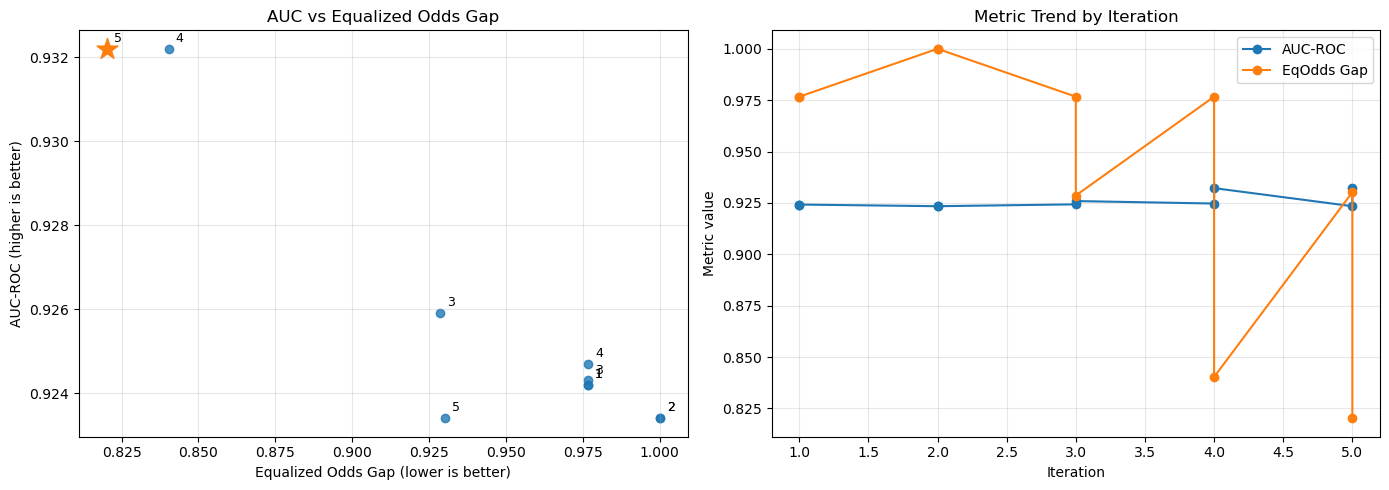

Winner based on objective score:
  Iteration 5: iter_5_best_family_fairness_tuned
  AUC-ROC=0.9322, EqOdds gap=0.8202, Objective=0.8092


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Mixed-schema safe reader: skips malformed rows instead of failing.
log_df = pd.read_csv('experiment_log.csv', engine='python', on_bad_lines='skip')

if log_df.empty:
    print('experiment_log.csv is empty or has no readable rows. Run Cell 7 first.')
else:
    # Support both schemas:
    # - New schema from auto-researcher: eq_odds_gap_overall + objective_score
    # - Older schema: eq_odds_gap
    if 'eq_odds_gap_overall' not in log_df.columns and 'eq_odds_gap' in log_df.columns:
        log_df['eq_odds_gap_overall'] = log_df['eq_odds_gap']

    if 'objective_score' not in log_df.columns:
        # fallback objective if older rows only
        log_df['objective_score'] = pd.NA

    # Keep only rows with numeric iteration + metrics
    for col in ['iteration', 'auc_roc', 'eq_odds_gap_overall', 'objective_score']:
        if col in log_df.columns:
            log_df[col] = pd.to_numeric(log_df[col], errors='coerce')

    required = ['iteration', 'auc_roc', 'eq_odds_gap_overall']
    missing = [c for c in required if c not in log_df.columns]
    if missing:
        print(f"Cannot plot yet. Missing columns: {missing}")
    else:
        plot_df = log_df.dropna(subset=required).copy()
        if plot_df.empty:
            print('No valid experiment rows found. Re-run Cell 7 to append clean rows.')
        else:
            # If objective unavailable for some rows, compute fallback objective
            if plot_df['objective_score'].isna().all():
                plot_df['objective_score'] = plot_df['auc_roc'] - 0.15 * plot_df['eq_odds_gap_overall']

            plot_df = plot_df.sort_values('iteration')

            winner_idx = plot_df['objective_score'].idxmax()
            winner = plot_df.loc[winner_idx]

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Plot 1: fairness-performance frontier view
            ax = axes[0]
            ax.scatter(plot_df['eq_odds_gap_overall'], plot_df['auc_roc'], alpha=0.8)
            for _, row in plot_df.iterrows():
                ax.annotate(int(row['iteration']), (row['eq_odds_gap_overall'], row['auc_roc']),
                            textcoords='offset points', xytext=(5, 5), fontsize=9)
            ax.scatter([winner['eq_odds_gap_overall']], [winner['auc_roc']], marker='*', s=250)
            ax.set_title('AUC vs Equalized Odds Gap')
            ax.set_xlabel('Equalized Odds Gap (lower is better)')
            ax.set_ylabel('AUC-ROC (higher is better)')
            ax.grid(alpha=0.3)

            # Plot 2: iteration trend
            ax2 = axes[1]
            ax2.plot(plot_df['iteration'], plot_df['auc_roc'], marker='o', label='AUC-ROC')
            ax2.plot(plot_df['iteration'], plot_df['eq_odds_gap_overall'], marker='o', label='EqOdds Gap')
            ax2.set_title('Metric Trend by Iteration')
            ax2.set_xlabel('Iteration')
            ax2.set_ylabel('Metric value')
            ax2.grid(alpha=0.3)
            ax2.legend()

            plt.tight_layout()
            plt.show()

            exp_name = winner['experiment_name'] if 'experiment_name' in plot_df.columns else 'N/A'
            print('Winner based on objective score:')
            print(f"  Iteration {int(winner['iteration'])}: {exp_name}")
            print(f"  AUC-ROC={winner['auc_roc']:.4f}, EqOdds gap={winner['eq_odds_gap_overall']:.4f}, Objective={winner['objective_score']:.4f}")